# Constrained vs. unconstrained control-law comparison

For each example (Dubins car, 2-DoF manipulator) this compares the two synthesized
reach-avoid control laws over the feedback-linearizable (FL) region:

- **ours (constrained)** — `sop_bounded_control_<sys>_result.py`, the SOP design with input-bound
  constraints enforced at sampled points (k1 is the decision variable);
- **unconstrained** — `sop_bounded_control_<sys>_unconstrained.py`, the vanilla backstepping design.

It reports, per control channel: the achieved range of each law, the **pointwise difference**
`|ours - unconstrained|` over the reach-avoid region, the fraction within a reference bound, and
the k1 magnitude; then draws side-by-side + difference heatmaps on a 2-D slice.

Question this answers: does enforcing the input bound through the SOP actually produce a
_different_, more bound-respecting controller than the unconstrained one?

Run the MATLAB examples first so the controller files exist:

```
matlab -batch "addpath('matlab'); example_dubins_car"
matlab -batch "addpath('matlab'); example_manipulator"
```


In [1]:
import os, importlib.util
import numpy as np, sympy as sp
import matplotlib.pyplot as plt

ROOT = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(ROOT, "controllers")) and os.path.isdir(
        os.path.join(ROOT, "matlab")
    ):
        break
    ROOT = os.path.dirname(ROOT)
CTRL = os.path.join(ROOT, "controllers")
print("controllers dir:", CTRL)

controllers dir: /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/controllers


## 1. Per-example configuration

State variable order, FL sampling box, control-channel labels, a reference input bound (for the
"% within bound" column), and the 2-D heatmap slice (which two state dims to vary; the rest fixed).


In [2]:
PI = np.pi
EXAMPLES = {
    "dubins_car": dict(
        result="sop_bounded_control_dubins_car_result.py",
        uncon="sop_bounded_control_dubins_car_unconstrained.py",
        vars=["x1", "x2", "th", "v"],
        lo=[-2, -2, 2 * PI / 3, 0.1],
        hi=[2, 2, 4 * PI / 3, 1.0],
        channels=["u1 (omega)", "u2 (a)"],
        ref_bound=[5.0, 5.0],
        slice=dict(dims=(0, 1), fixed={2: PI, 3: 0.5}),
    ),
    "manipulator": dict(
        result="sop_bounded_control_acrobot_result.py",
        uncon="sop_bounded_control_acrobot_unconstrained.py",
        vars=["x1", "x2", "x3", "x4"],
        lo=[-2.0, 0.8, -0.5, -0.5],
        hi=[0.5, PI - 0.8, 0.5, 0.5],
        channels=["tau1", "tau2"],
        ref_bound=[500.0, 500.0],
        slice=dict(dims=(0, 1), fixed={2: 0.0, 3: 0.0}),
    ),
}
N_SAMPLES = 200000

## 2. Loaders / helpers


In [3]:
def k1_coeff_norm(k1_opt):
    """L2 norm of all polynomial coefficients of the k1 vector."""
    coeffs = []
    for e in (list(k1_opt) if k1_opt is not None else []):
        e = sp.expand(sp.sympify(e))
        fs = list(e.free_symbols)
        coeffs += [float(c) for c in (sp.Poly(e, *fs).coeffs() if fs else [e])]
    return float(np.sqrt(sum(c * c for c in coeffs))) if coeffs else 0.0


def load_ctrl(fname, varnames):
    spec = importlib.util.spec_from_file_location("m", os.path.join(CTRL, fname))
    m = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(m)
    free = set(sp.Matrix(m.u_opt).free_symbols) | set(m.certificate_opt.free_symbols)
    syms = {s.name: s for s in free}
    order = [syms[n] for n in varnames if n in syms]
    present = [n for n in varnames if n in syms]
    us = [sp.lambdify(order, ui, "numpy") for ui in m.u_opt]
    cert = sp.lambdify(order, m.certificate_opt, "numpy")
    return us, cert, present, k1_coeff_norm(m.k1_opt)


def eval_args(X, varnames, present):
    return [X[:, i] for i, n in enumerate(varnames) if n in present]

## 3. Range, pointwise difference, %-within-bound (over the reach-avoid region)

Both laws are evaluated on the same points (ours' certificate >= 0).


In [4]:
summary = []
for name, cfg in EXAMPLES.items():
    vn = cfg["vars"]
    lo = np.array(cfg["lo"])
    hi = np.array(cfg["hi"])
    us_o, cert_o, pres, k1n_o = load_ctrl(cfg["result"], vn)
    us_u, cert_u, _, k1n_u = load_ctrl(cfg["uncon"], vn)
    np.random.seed(1)
    X = np.random.rand(N_SAMPLES, len(vn)) * (hi - lo) + lo
    a = eval_args(X, vn, pres)
    inreg = np.atleast_1d(cert_o(*a)) >= 0
    print(
        f"\n=== {name} ===  in-region(ours cert>=0)={int(inreg.sum())},  "
        f"||k1||: ours={k1n_o:.3e}  unconstrained={k1n_u:.3e}"
    )
    for c, lab in enumerate(cfg["channels"]):
        Uo = np.atleast_1d(us_o[c](*a))
        Uu = np.atleast_1d(us_u[c](*a))
        ok = inreg & np.isfinite(Uo) & np.isfinite(Uu)
        d = np.abs(Uo[ok] - Uu[ok])
        ub = cfg["ref_bound"][c]
        row = dict(
            system=name,
            channel=lab,
            ours_min=float(Uo[ok].min()),
            ours_max=float(Uo[ok].max()),
            unc_min=float(Uu[ok].min()),
            unc_max=float(Uu[ok].max()),
            max_abs_diff=float(d.max()),
            mean_abs_diff=float(d.mean()),
            ours_pct_within=100 * float(np.mean(np.abs(Uo[ok]) <= ub)),
            unc_pct_within=100 * float(np.mean(np.abs(Uu[ok]) <= ub)),
            ref_bound=ub,
        )
        summary.append(row)
        print(
            f"  {lab:12s} ours=[{row['ours_min']:9.2f},{row['ours_max']:9.2f}]  "
            f"unc=[{row['unc_min']:9.2f},{row['unc_max']:9.2f}]  "
            f"max|diff|={row['max_abs_diff']:.3e}  "
            f"within +-{ub:g}: ours={row['ours_pct_within']:.1f}% unc={row['unc_pct_within']:.1f}%"
        )
try:
    import pandas as pd

    display(pd.DataFrame(summary))
except Exception:
    pass


=== dubins_car ===  in-region(ours cert>=0)=82348,  ||k1||: ours=2.662e-05  unconstrained=6.850e-07
  u1 (omega)   ours=[   -90.83,    94.75]  unc=[   -90.83,    94.75]  max|diff|=6.879e-05  within +-5: ours=65.7% unc=65.7%
  u2 (a)       ours=[   -11.42,     9.19]  unc=[   -11.42,     9.19]  max|diff|=5.750e-05  within +-5: ours=93.5% unc=93.5%

=== manipulator ===  in-region(ours cert>=0)=3126,  ||k1||: ours=8.876e+00  unconstrained=7.762e+00
  tau1         ours=[ -5228.20,  5573.92]  unc=[ -5231.34,  5568.34]  max|diff|=1.147e+01  within +-500: ours=10.8% unc=10.8%
  tau2         ours=[  -242.30,   692.22]  unc=[  -237.77,   693.15]  max|diff|=5.904e+00  within +-500: ours=98.6% unc=98.6%


,system,channel,ours_min,ours_max,unc_min,unc_max,max_abs_diff,mean_abs_diff,ours_pct_within,unc_pct_within,ref_bound
0,dubins_car,u1 (omega),-90.827587,94.747286,-90.827566,94.747284,0.000069,0.000014,65.699228,65.699228,5.0
1,dubins_car,u2 (a),-11.416883,9.188524,-11.416879,9.188533,0.000058,0.000009,93.512896,93.512896,5.0
2,manipulator,tau1,-5228.198923,5573.920378,-5231.342903,5568.338118,11.473247,2.621074,10.780550,10.812540,500.0
3,manipulator,tau2,-242.301513,692.217041,-237.766523,693.154796,5.903647,1.605283,98.592450,98.592450,500.0


## 4. Heatmaps: ours vs. unconstrained vs. difference (2-D slice)

If the SOP changed the controller, the difference panel will be non-trivial; if the two laws are
the same, it will be ~0 (note the colorbar scale).


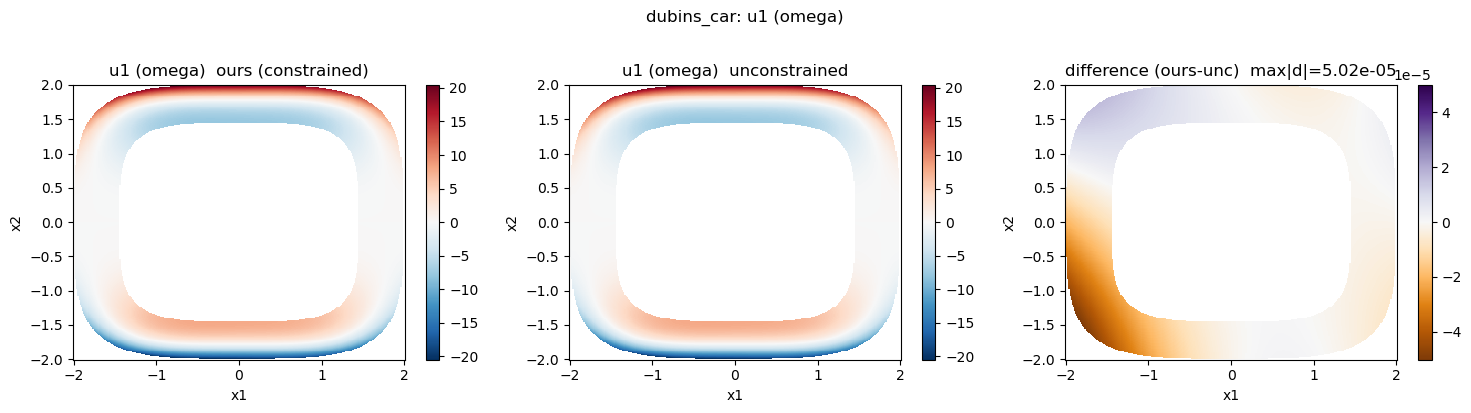

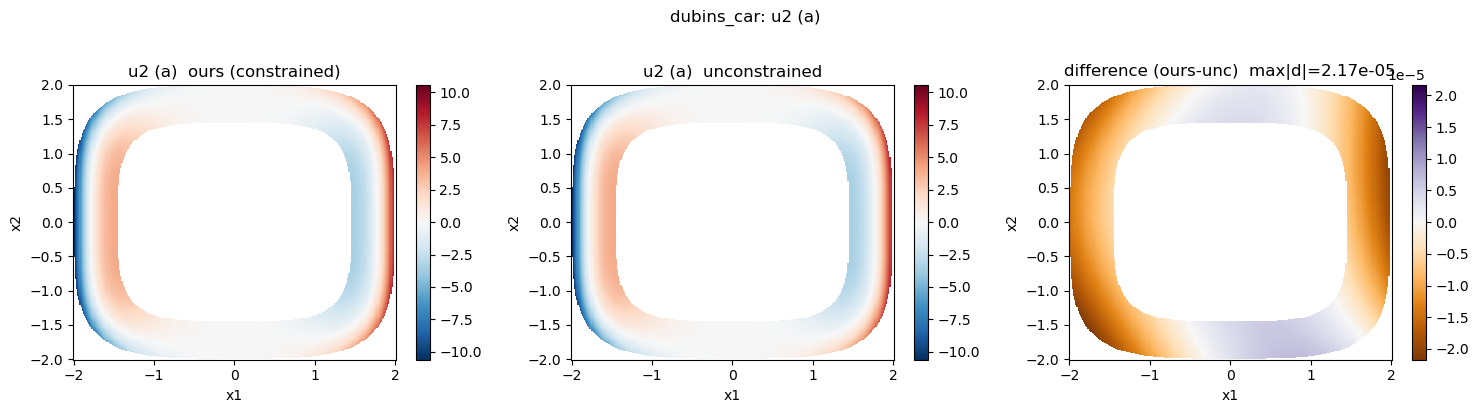

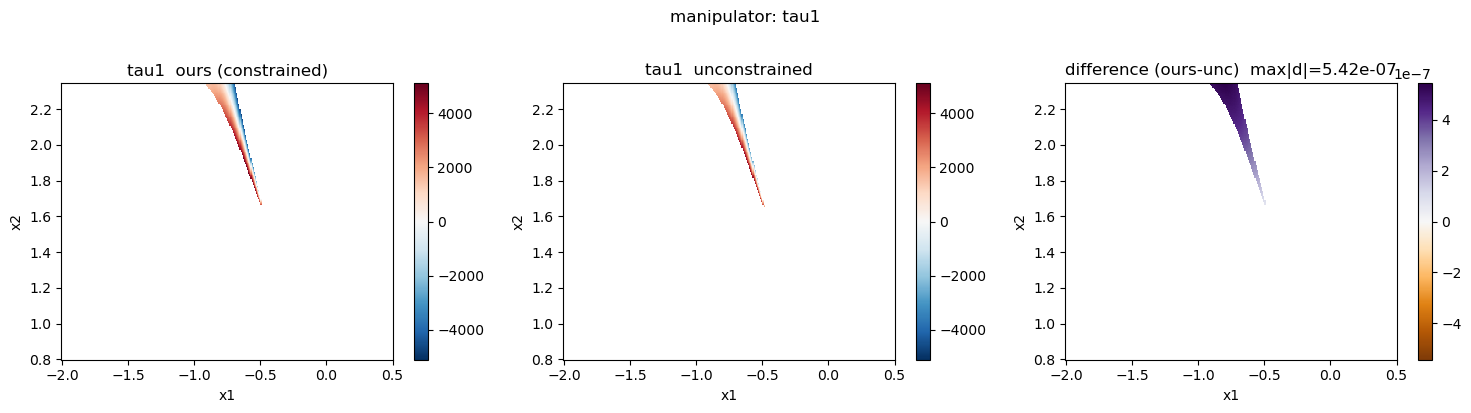

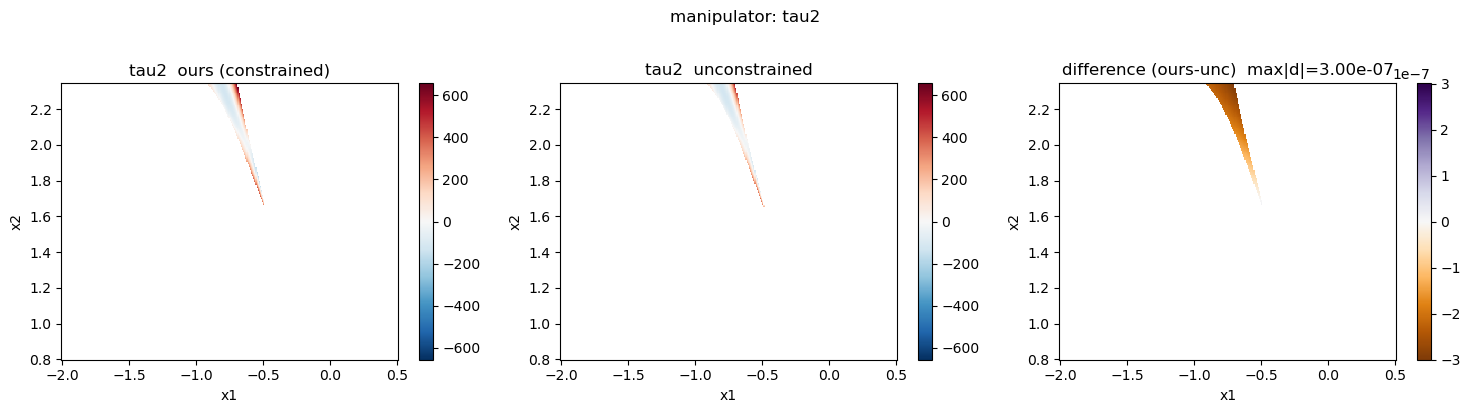

In [5]:
def slice_eval(uf, certf, cfg, vn, present, n=300):
    d0, d1 = cfg["slice"]["dims"]
    lo = cfg["lo"]
    hi = cfg["hi"]
    g0 = np.linspace(lo[d0], hi[d0], n)
    g1 = np.linspace(lo[d1], hi[d1], n)
    G0, G1 = np.meshgrid(g0, g1)
    cols = []
    for i in range(len(vn)):
        if i == d0:
            cols.append(G0)
        elif i == d1:
            cols.append(G1)
        else:
            cols.append(np.full_like(G0, cfg["slice"]["fixed"][i]))
    a = [cols[i] for i, n_ in enumerate(vn) if n_ in present]
    U = uf(*a)
    C = certf(*a)
    return G0, G1, np.where(C >= 0, U, np.nan)


for name, cfg in EXAMPLES.items():
    vn = cfg["vars"]
    us_o, cert_o, pres, _ = load_ctrl(cfg["result"], vn)
    us_u, cert_u, _, _ = load_ctrl(cfg["uncon"], vn)
    d0, d1 = cfg["slice"]["dims"]
    for c, lab in enumerate(cfg["channels"]):
        G0, G1, Uo = slice_eval(us_o[c], cert_o, cfg, vn, pres)
        _, _, Uu = slice_eval(us_u[c], cert_u, cfg, vn, pres)
        vmax = np.nanmax(
            np.abs([np.nanmin(Uo), np.nanmax(Uo), np.nanmin(Uu), np.nanmax(Uu)])
        )
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        for a_, U, t in [
            (ax[0], Uo, "ours (constrained)"),
            (ax[1], Uu, "unconstrained"),
        ]:
            im = a_.pcolormesh(
                G0, G1, U, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto"
            )
            a_.set_title(f"{lab}  {t}")
            a_.set_xlabel(vn[d0])
            a_.set_ylabel(vn[d1])
            plt.colorbar(im, ax=a_)
        D = Uo - Uu
        dm = np.nanmax(np.abs(D))
        dm = dm if np.isfinite(dm) and dm > 0 else 1.0
        im = ax[2].pcolormesh(G0, G1, D, cmap="PuOr", vmin=-dm, vmax=dm, shading="auto")
        ax[2].set_title(f"difference (ours-unc)  max|d|={dm:.2e}")
        ax[2].set_xlabel(vn[d0])
        ax[2].set_ylabel(vn[d1])
        plt.colorbar(im, ax=ax[2])
        fig.suptitle(f"{name}: {lab}", y=1.02)
        fig.tight_layout()
        plt.show()